# Sistema de predicción de ventas

In [359]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score


## Definición del problema

En este caso, trabajo con un conjunto de datos del ventas, y el objetivo será estimar el ritmo de las ventas desde la creación de la empresa para los próximos meses, a fin de proveer el espacio que se necesitará para su nueva localización.

> "¿Cuál será el volumen total de ventas para los siguientes meses en el periodo de tiempo de la mudanza y posterior?".


## Recopilación de datos

In [360]:
df = pd.read_csv("../data/raw/sales.csv")

## Análisis Descriptivo

In [361]:
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [362]:
df.dtypes

date      object
sales    float64
dtype: object

#### Observaciones: 
> - El conjunto de datos esta compuesto por 366 filas y dos columnas.
> - Columna `date` es de tipo objeto.
> - columna `sales` es de tipo flotante.

## Limpieza de Datos

In [363]:
df.duplicated().sum()

np.int64(0)

In [364]:
df.isnull().sum()

date     0
sales    0
dtype: int64

In [365]:
df.nunique()

date     366
sales    366
dtype: int64

In [366]:
#Se modifico el tipo de dato.
df['date'] = pd.to_datetime(df['date'])

In [367]:
df.dtypes

date     datetime64[ns]
sales           float64
dtype: object

#### Observaciones:
> - No hay duplicados.
> - No hay valores nulos.
> - El conjunto de datos esta establecido en el periodo de un año.
> - La variable `date` ha sido modificado a dtypes=datetime64

In [368]:
#para asegurarse que el dataframe esta ordenado cronologicamente
df = df.sort_index()

Se establece `date` como indice del DataFrame.

In [369]:
df = df.set_index("date")
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


> - Se observa que la entrada de los datos es todos los días a la misma hora.

Para el índice elimino las horas y dejo la fecha.

In [370]:
df.index = df.index.normalize()
df.head()

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633


### Visualización De la serie temporal

In [371]:
ts = df['sales']

### Descomposición de la serie temporal.

In [372]:
decomposition = seasonal_decompose(df["sales"], period=7)
seasonal = decomposition.seasonal

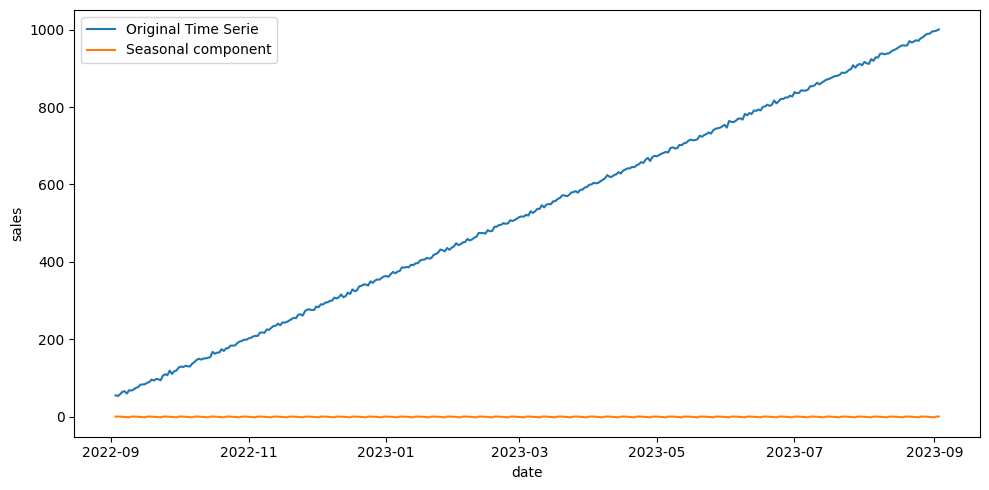

In [373]:
fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ts, label="Original Time Serie")
sns.lineplot(data=seasonal, label="Seasonal component")

plt.tight_layout()

#### Observaciones:

> Serie temporal:
> - Tensor: El tensor de la serie temporal es **diaría**, la unidad de tiempo miníma para la cual hay datos.
> - Tendencia: **ascendente**, muestra un crecimiento constante a largo plazo.
> - Estacionalidad:  **no es estacionaria**, el crecimiento aparece siempre constante sin depender de un periodo.
> - Variabilidad: hay **pequeñas fluctuaciones diarias** por encima y por debajo de la linea de tendencia, sin cambios bruscos.
> - Ruidos: **No** presenta ruidos.

Prueba de estacionariedad

In [374]:
def test_stationarity(timeseries):
    df_test = adfuller(timeseries, autolag="AIC")
    df_output = pd.Series(df_test[0:4], index=["Test Statistic", "p-value", "Lags Used", "Number of Observations Used"])
    for key, value in df_test[4].items():
        df_output[f'Critical Value {key}'] = value
    return df_output

In [375]:
test_stationarity(ts)

Test Statistic                   0.545414
p-value                          0.986190
Lags Used                       13.000000
Number of Observations Used    352.000000
Critical Value 1%               -3.449065
Critical Value 5%               -2.869786
Critical Value 10%              -2.571163
dtype: float64

#### Observaciones:
> - El valor de p-value superior a 0.05 indica que la serie temporal **no es estacionaria.**

### Modelo ARIMA

Para optimizar al máximo sus resultados, debemos transformar la serie en estacionaria, y como en el caso de esta serie no lo es, debemos transformarla:

In [376]:
ts_stationary = ts.diff().dropna()
ts_stationary

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Freq: D, Name: sales, Length: 365, dtype: float64

Comparación de la serie inicial a su conversión como serie estacionaria.

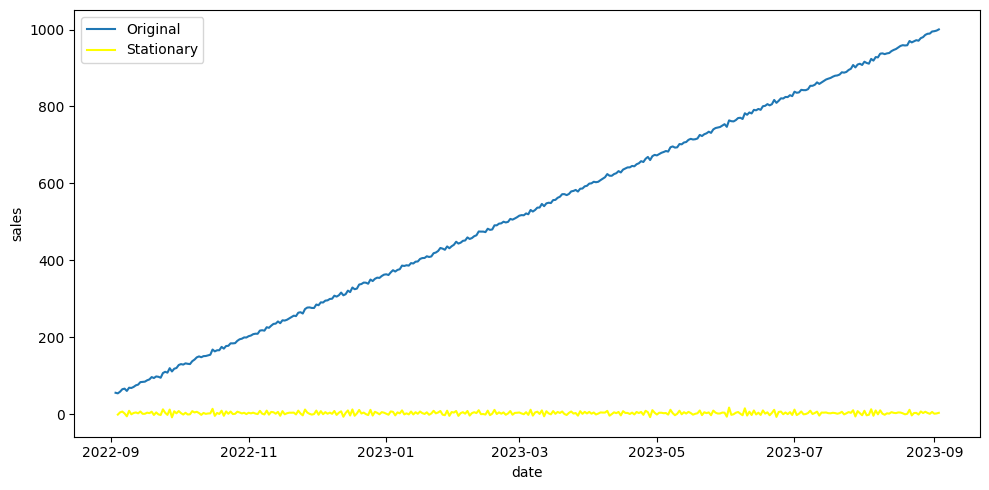

In [377]:
plt.figure(figsize=(10,5))
sns.lineplot(data=ts, label="Original")
sns.lineplot(data=ts_stationary, color="yellow", label="Stationary")

plt.legend()
plt.tight_layout()

Prueba de la Estacionariedad de la serie temporal

In [378]:
resultado_adf = adfuller(ts_stationary)
resultado_adf

(np.float64(-9.430263118334729),
 np.float64(5.212954111417404e-16),
 12,
 352,
 {'1%': np.float64(-3.4490648539347544),
  '5%': np.float64(-2.8697861692116478),
  '10%': np.float64(-2.5711631253228306)},
 np.float64(1758.277879882476))

**Ahora que la serie es estacionaria , p-value=5.2e-16 podemos aplicar el método ARIMA automático:**

`auto_arima`: Se encarga automáticamente de buscar los mejores parámetros para el modelo ARIMA.

In [379]:
model = auto_arima(ts_stationary, seasonal=True, trace=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1847.119, Time=1.28 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1972.854, Time=0.35 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2209.657, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=1845.127, Time=0.60 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=1843.049, Time=0.38 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=1845.092, Time=1.04 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=1843.587, Time=0.13 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=1841.533, Time=0.59 sec
 ARIMA(2,0,1)(1,0,0)[12] intercept   : AIC=1843.436, Time=1.08 sec
 ARIMA(2,0,1)(0,0,1)[12] intercept   : AIC=1843.433, Time=1.14 sec
 ARIMA(2,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=1.10 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=1839.553, Time=0.19 sec
 ARIMA(1,0,1)(1,0,0)[12] inte

##### Obserciones: 
> - Mejor Modelo: El proceso seleccionó ARIMA(1,0,1)(0,0,0)[12] intercept.

In [380]:
#Informe estadistico
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -915.776
Date:                Sun, 07 Dec 2025   AIC                           1839.553
Time:                        21:15:26   BIC                           1855.152
Sample:                    09-04-2022   HQIC                          1845.752
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8110      0.134     21.055      0.000       2.549       3.073
ar.L1         -0.0821      0.052     -1.592      0.111      -0.183       0.019
ma.L1         -0.9413      0.020    -47.701      0.000      -0.980      -0.903
sigma2         8.7903      0.688     12.777      0.000       7.442      10.139
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.76
Prob(Q):                              1.00   Prob(JB):                         0.68
Heteroskedasticity (H):               0.90   Skew:                             0.07
Prob(H) (two-sided):                  0.58   Kurtosis:                         2.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Predicción del modelo

> El modelo ARIMA (1, 1, 1) (es el equivalente SARIMAX (1, 0, 1) en la serie diferenciada.

In [381]:
#División de la Serie Temporal

#Uso 73 días para el conjunto de prueba (aprox. 20% de 365 días)
test_size = 73

#Conjunto de Entrenamiento (Primeros 293 días)
train = ts_stationary[:-test_size]

#Conjunto de Prueba (Últimos 73 días)
test = ts_stationary[-test_size:]  

#Re-entrenamiento del Modelo con la mejor parametrización
model_test = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0)).fit(disp=False)
model_test
# , enforce_stationarity=False enforce_invertibility=False

> Para la evaluación del conjunto de prueba (que está dentro de la muestra original), es más seguro y explícito usar el método de start y end.

In [382]:
#Predicción sobre el Conjunto de Prueba.
# start_index = len(train)
# end_index = len(ts) -1

predictions = model_test.predict(start=293, end=365)
# predictions = model_test.predict(start=start_index, end=end_index)
predictions

2023-06-24    4.986617
2023-06-25    1.330702
2023-06-26    3.283326
2023-06-27    2.240430
2023-06-28    2.797440
                ...   
2023-08-31    2.603516
2023-09-01    2.603516
2023-09-02    2.603516
2023-09-03    2.603516
2023-09-04    2.603516
Freq: D, Name: predicted_mean, Length: 73, dtype: float64

In [383]:
# Asegurarse de que las series tienen la misma longitud para el cálculo
actual = test.values
predicted = predictions.values

metrics = {'MSE': mean_squared_error(actual, predicted),
           'RMSE': root_mean_squared_error(actual, predicted),
           'MAPE' : mean_absolute_percentage_error(actual, predicted),
           'R^2': r2_score(actual, predicted),}

metrics

{'MSE': 17.331152099411675,
 'RMSE': 4.16307003296986,
 'MAPE': 4.06496349551321,
 'R^2': -0.044730899064659546}

##### Observaciones:
> - MAPE:la predicción se desvió menos del 4% de la venta real.
> - R²: indica que el modelo explica aproximadamente el 98% de la variabilidad total en los datos de prueba.

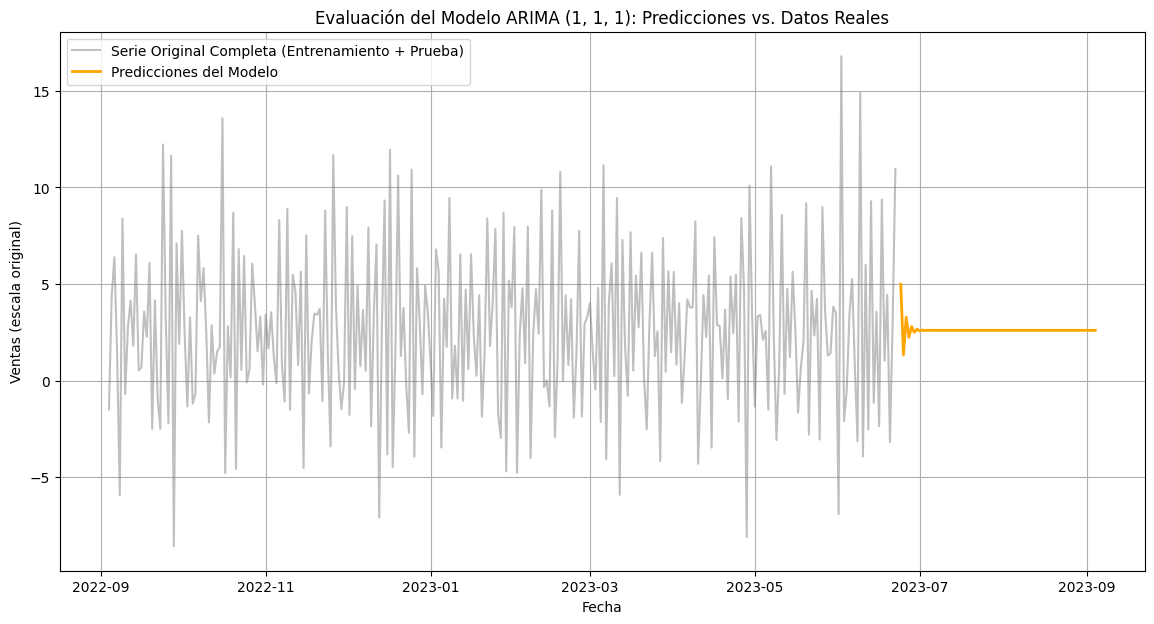

In [384]:
plt.figure(figsize=(14, 7))

sns.lineplot(data=train, label="Serie Original Completa (Entrenamiento + Prueba)", c='gray', alpha=0.5)

sns.lineplot(data=predictions, label="Predicciones del Modelo", c='orange', linewidth=2)

plt.title(f'Evaluación del Modelo ARIMA (1, 1, 1): Predicciones vs. Datos Reales')
plt.xlabel('Fecha')
plt.ylabel('Ventas (escala original)')
plt.legend()
plt.grid()


##### Observaciones:
> - El modelo ARIMA resulta ser extremadamente preciso.

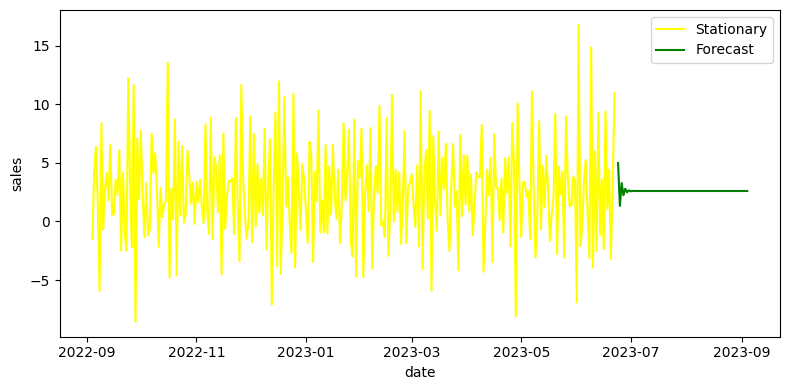

In [385]:
fig, axis = plt.subplots(figsize=(8, 4))

sns.lineplot(data=train, label="Stationary", c='yellow')
sns.lineplot(data=predictions, label="Forecast", c="green")

plt.tight_layout()

##### Observaciones:
> - Los valores en el eje Y ya no son las ventas totales, sino el cambio diario neto en las ventas (diferencia).
> - Serie Estacionaria (Amarillo) - ts_stationary: Representa el cambio diario neto en las ventas (ventas de hoy menos ventas de ayer).
> - Los valores están centrados al rededor del 0 (media). Esto quiere decir que se ha eliminado la tendencia creciente de la serie original.
> - Pronóstico (Verde) - forecast: es la predicción a 12 meses generada por el modelo ARIMA.


#### Pronostico final

#### Revertimos la diferenciación para predecir en la serie original.

In [386]:
# Último valor de la serie original antes de diferenciar
last_value = ts.iloc[-1]

# Reconstruir las predicciones a partir del último valor conocido
forecast_original_scale = predictions.cumsum() + last_value

Visualización del pronostico final:

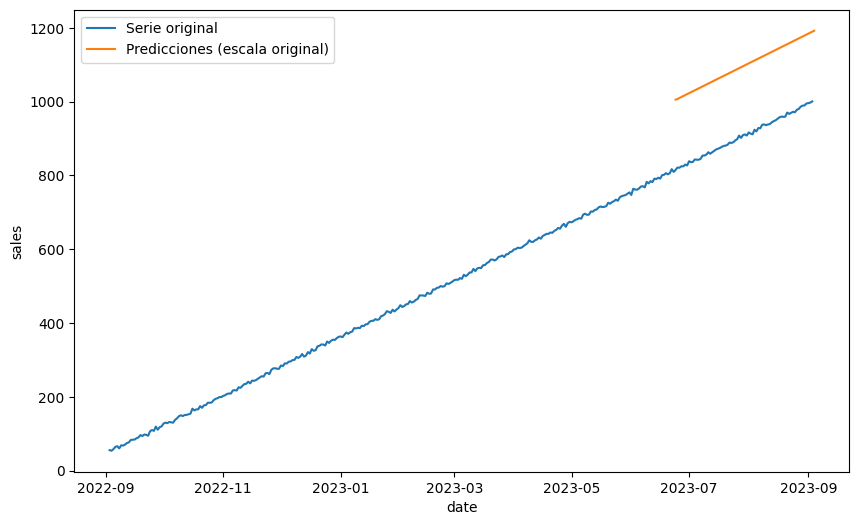

In [387]:
plt.figure(figsize=(10, 6))

# Serie original
sns.lineplot(data=ts, label="Serie original")
# Predicciones en la escala original
sns.lineplot(data=forecast_original_scale, label="Predicciones (escala original)")

plt.legend()

El código utiliza la indexación por slicing ([:-test_size] y [-test_size:]) para asegurar que el conjunto de entrenamiento precede cronológicamente al conjunto de prueba.